In [1]:
import awkward as ak
import fastjet as fj
import matplotlib.pyplot as plt
import numpy as np
import uproot

In [2]:
def get_pj_array(four_vectors: ak.Array) -> list[fj.PseudoJet]:
    pj_array: list[fj.PseudoJet] = []

    for i, part in enumerate(four_vectors):
        pj = fj.PseudoJet(part.px.item(), part.py.item(), part.pz.item(), part.E.item())
        pj.set_user_index(i)
        pj_array.append(pj)
    return pj_array

In [3]:
def get_cluster_sequence(
    jet_definition: fj.JetDefinition,
    four_vectors: ak.Array,
    user_indices: list[int] | None = None,
    area_spec: fj.GhostedAreaSpec | None = None,
) -> tuple[fj.ClusterSequence | fj.ClusterSequenceArea, list[fj.PseudoJet]]:
    pj_array: list[fj.PseudoJet] = []

    for i, part in enumerate(four_vectors):
        pj = fj.PseudoJet(part.px.item(), part.py.item(), part.pz.item(), part.E.item())
        if user_indices is not None:
            pj.set_user_index(user_indices[i])
        else:
            pj.set_user_index(i)
        pj_array.append(pj)
    if area_spec is not None:
        return fj.ClusterSequenceArea(pj_array, jet_definition, area_spec), pj_array
    return fj.ClusterSequence(pj_array, jet_definition), pj_array

In [4]:
from particle import PDGID
def pid_to_class(pid: int) -> int:
    if abs(pid) == 11:
        return 1
    if abs(pid) == 13:
        return 2
    p = PDGID(pid)
    if p.is_hadron:
        if p.charge != 0:
            return 0
        return 3
    return 4

In [18]:
# with uproot.open("zzto4mu_test.root") as f:
# with uproot.open("ttbar_test.root") as f:
with uproot.open("vbfh4lep_test.root") as f:
    tree = f["pfcs/Events"]
    data = {}
    data_muons = {}
    for key in tree.keys():
        print(key)
        if key.startswith("PFCand_"):
            data[key.split("_")[-1]] = tree[key].array(library="np")
    tree = f['mymuons/Events']
    for key in tree.keys():
        print(key)
        if key.startswith("muon_"):
            data_muons[key.split("_")[-1]] = tree[key].array(library="np")
    data['class_id'] = np.array([
        np.vectorize(pid_to_class)(data['pdgId'][i])
        for i in range(len(data['pdgId']))
    ], dtype=object)
    data['rho'] = f['events/Events']['rhoIso'].array(library="np")

numPFCand
PFCand_pt
PFCand_eta
PFCand_mass
PFCand_pdgId
PFCand_phi
PFCand_px
PFCand_py
PFCand_pz
PFCand_vx
PFCand_vy
PFCand_vz
PFCand_jetIdx
PFCand_d0
PFCand_d0Error
PFCand_z0
PFCand_z0Error
PFCand_ip3d
PFCand_ip3dError
numbermuon
muon_e
muon_pt
muon_px
muon_py
muon_pz
muon_eta
muon_phi
muon_ch
muon_mass
muon_pfreliso03all
muon_pfreliso04all
muon_isoChargedPtSum
muon_isoNeutralPtSum
muon_isoPhotonPtSum
muon_tightid
muon_softid
muon_dxy
muon_dxyErr
muon_dz
muon_dzErr
muon_jetidx
muon_genpartidx


In [19]:
def mask_pt(data: dict, pt_cut=1):
    mask = [el > pt_cut for el in data['pt']]
    for key in data.keys():
        if key == 'rho':
            continue
        for i in range(len(data[key])):
            data[key][i] = data[key][i][mask[i]]
    return data


In [20]:
def mask_pdgId(data: dict):
    mask = []
    for el in data['pdgId']:
        quark_mask = np.abs(el) > 8
        boson_mask = np.isin(np.abs(el), [21, 23, 24, 25, 32, 33, 34,35,36,37], invert=True)
        mask.append(np.logical_and(quark_mask, boson_mask))
    for key in data.keys():
        if key == 'rho':
            continue
        for i in range(len(data[key])):
            data[key][i] = data[key][i][mask[i]]
    return data


In [21]:
def to_ak_4vec(pt, eta, phi):
    return ak.Array(
        {
            "px": pt * np.cos(phi),
            "py": pt * np.sin(phi),
            "pz": pt * np.sinh(eta),
            "E": pt * np.cosh(eta),
        }
    )

In [22]:
jet_def_bkgd = fj.JetDefinition(fj.kt_algorithm, 0.4)
area_def_bkgd = fj.AreaDefinition(fj.active_area_explicit_ghosts,
                fj.GhostedAreaSpec(6))
# selector = fj.SelectorAbsRapMax(4.5) # * (~fj.SelectorNHardest(2))
# bkgd_estimator = fj.JetMedianBackgroundEstimator(selector, jet_def_bkgd, area_def_bkgd)
bkgd_estimator = fj.GridMedianBackgroundEstimator(5, 0.55)

In [49]:
def calculate_rho(pt, eta, phi, pt_cut = 0):
    mask = pt > pt_cut
    pt, eta, phi = pt[mask], eta[mask], phi[mask]
    pj_array = get_pj_array(to_ak_4vec(pt, eta, phi))
    bkgd_estimator.set_particles(pj_array)
    bkgd_estimate = bkgd_estimator.estimate()
    rho = bkgd_estimate.rho()

    return rho

In [50]:
rho = [
    calculate_rho(data['pt'][i], data['eta'][i], data['phi'][i], pt_cut=0)
    for i in range(len(data['pt']))
]

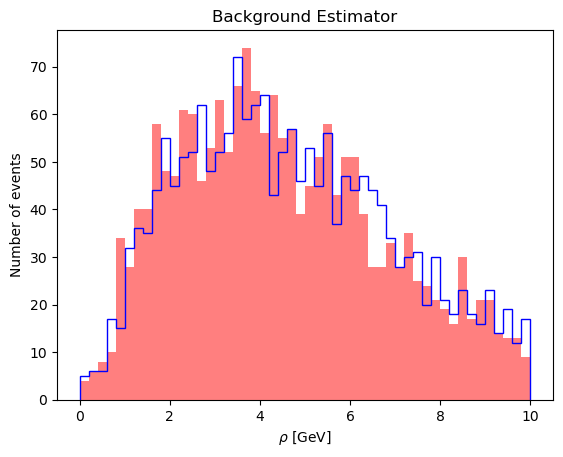

In [51]:
plt.hist(
    data['rho'],
    bins=50,
    range=(0, 10),
    histtype="stepfilled",
    color="red",
    alpha=0.5,
    label="rho from tree",
)
plt.hist(
    np.array(rho),
    bins=50,
    range=(0, 10),
    histtype="step",
    color="blue",
)
plt.xlabel(r"$\rho$ [GeV]")
plt.ylabel("Number of events")
plt.title("Background Estimator")
plt.show()

In [23]:
mask_pdgId(data)

{'pt': array([array([76.96886   , 60.541756  ,  0.59314036, 46.064404  , 15.536089  ,
                3.8164182 ,  5.6023    ,  2.2891223 ,  4.4855776 ,  2.3580043 ,
                2.141029  ,  1.2980678 ,  0.3968455 ,  0.46826297,  0.9337234 ,
                0.17018142,  0.49128184,  0.46419933,  0.57591265,  0.4685676 ,
                0.45612216,  0.7779923 ,  0.4972806 ,  2.5171494 ,  3.333372  ,
                1.0956879 ,  0.79447395,  2.300402  ,  0.36378148,  0.70297885,
                0.71021825,  0.4030229 ,  0.209129  , 16.342716  ,  0.88297933,
                0.85842025,  0.63310194,  1.2603945 ,  0.620041  ,  1.1234707 ,
                1.6160132 ,  3.3998697 ,  0.9347166 ,  0.49210095,  0.5191752 ,
                0.41312423,  0.519068  ,  2.3356853 ,  2.601159  ,  0.2814243 ,
                0.36528546,  1.2250617 ,  0.5394053 ,  0.711123  ,  0.25617364,
                0.30640912,  0.8482822 ,  1.1933364 ,  1.1947445 ,  1.553207  ,
                4.1257963 ,  5.072

In [24]:
mask_pt(data, pt_cut=1)

{'pt': array([array([76.96886  , 60.541756 , 46.064404 , 15.536089 ,  3.8164182,
                5.6023   ,  2.2891223,  4.4855776,  2.3580043,  2.141029 ,
                1.2980678,  2.5171494,  3.333372 ,  1.0956879,  2.300402 ,
               16.342716 ,  1.2603945,  1.1234707,  1.6160132,  3.3998697,
                2.3356853,  2.601159 ,  1.2250617,  1.1933364,  1.1947445,
                1.553207 ,  4.1257963,  5.07239  ,  1.377148 ,  1.553643 ,
                2.1259298,  1.648916 ,  3.072677 ,  1.2647189,  1.9652374,
                1.8387333,  1.8268063,  4.6913724,  1.1661696,  1.3684297,
                2.1264493,  2.6199126,  1.7726086,  1.155371 ,  1.1597474,
                1.4885489,  1.0252813,  1.1523166,  1.013095 ,  1.9084004,
                1.1703817,  1.3626604,  1.0130769,  1.0636295,  1.1349823],
              dtype=float32)                                               ,
        array([ 3.6677608, 29.786335 , 12.761477 ,  1.7048217,  2.4942584,
               4

In [25]:
def calculate_isolation(pt, eta, phi, class_id, dr_cut=0.5, pt_cut = 0):

    mask = pt > pt_cut
    pt, eta, phi, class_id = pt[mask], eta[mask], phi[mask], class_id[mask]
    pj_array = get_pj_array(to_ak_4vec(pt, eta, phi))
    bkgd_estimator.set_particles(pj_array)
    bkgd_estimate = bkgd_estimator.estimate()
    rho = bkgd_estimate.rho()
    area = bkgd_estimate.mean_area()
    lepton_mask = (class_id == 1) | (class_id == 2)
    ch_hadron_mask = class_id == 0
    neut_mask = (class_id == 3) | (class_id == 4)
    # print(pt.shape, eta.shape, phi.shape, class_id.shape, rho, area)
    leptons_eta = eta[lepton_mask]
    leptons_phi = phi[lepton_mask]
    dEta = leptons_eta[:, None] - eta[None, :]
    dPhi = leptons_phi[:, None] - phi[None, :]
    dPhi = np.atan2(np.sin(dPhi), np.cos(dPhi))
    dR = np.sqrt(dEta**2 + dPhi**2)

    dR_mask = dR < dr_cut
    iso_score = np.zeros(len(leptons_eta))
    for i in range(len(leptons_eta)):
        row_mask = dR_mask[i] & ~lepton_mask
        ch_pt_sum = pt[row_mask & ch_hadron_mask].sum()
        neut_pt_sum = pt[row_mask & neut_mask].sum()
        iso_score[i] = (ch_pt_sum + max(0, neut_pt_sum - rho * area)) / pt[lepton_mask][i]
    return iso_score

In [26]:
def calculate_isolation_v2(pt, eta, phi, class_id, dr_cut=0.4, pt_cut = 0):

    mask = pt > pt_cut
    pt, eta, phi, class_id = pt[mask], eta[mask], phi[mask], class_id[mask]
    # pj_array = get_pj_array(to_ak_4vec(pt, eta, phi))
    # bkgd_estimator.set_particles(pj_array)
    # bkgd_estimate = bkgd_estimator.estimate()
    # rho = bkgd_estimate.rho()
    # area = bkgd_estimate.mean_area()
    rho = 0
    area = 0
    lepton_mask = (class_id == 1) | (class_id == 2)
    ch_hadron_mask = class_id == 0
    neut_mask = (class_id == 3) | (class_id == 4)
    # neut_mask = (class_id == 3) # | (class_id == 4)
    # phot_mask = class_id == 4
    # print(pt.shape, eta.shape, phi.shape, class_id.shape, rho, area)
    dEta = eta[:, None] - eta[None, :]
    dPhi = phi[:, None] - phi[None, :]
    dPhi = np.atan2(np.sin(dPhi), np.cos(dPhi))
    dR = np.sqrt(dEta**2 + dPhi**2)

    dR_mask = dR < dr_cut
    pt_mat = pt
    ch_pt_sum = ((pt_mat * dR_mask) * ch_hadron_mask).sum(-1)
    neut_pt_sum = ((pt_mat * dR_mask) * neut_mask).sum(-1)
    iso_score = (ch_pt_sum + np.maximum(0, neut_pt_sum - rho * area)) / pt
    # neut_pt_sum = ((np.sqrt(pt_mat**2 + 0.939**2) * dR_mask) * neut_mask).sum(-1)
    # phot_pt_sum = ((pt_mat * dR_mask) * phot_mask).sum(-1)
    # iso_score = (ch_pt_sum + np.maximum(0, phot_pt_sum + neut_pt_sum - rho * area)) / pt
    iso_score[~lepton_mask] = -1000

    return iso_score

In [55]:
for i, el in enumerate(data['pdgId'][0]):
    print(i, pid_to_class(el), el)

0 1 -11
1 0 -211
2 4 22
3 0 -211
4 0 211
5 0 211
6 0 -211
7 0 211
8 4 22
9 3 130
10 0 211
11 0 -211
12 0 -211
13 0 211
14 4 22
15 3 130
16 0 211
17 0 211
18 0 -211
19 3 130
20 0 -211
21 0 -211
22 0 -211
23 0 211
24 3 130
25 3 130
26 0 211
27 3 130
28 0 211
29 0 211
30 0 211
31 3 130
32 4 22
33 2 13
34 0 211
35 0 211
36 0 -211
37 0 -211
38 0 211
39 0 -211
40 0 211
41 0 211
42 3 130
43 0 211
44 0 -211
45 0 211
46 0 -211
47 3 130
48 3 130
49 0 -211
50 0 -211
51 3 130
52 0 -211
53 3 130
54 3 130
55 4 22
56 0 211
57 0 211
58 0 -211
59 0 211
60 0 -211
61 2 -13
62 0 211
63 0 211
64 0 211
65 0 -211
66 0 -211
67 0 -211
68 3 130
69 0 -211
70 0 211
71 0 211
72 0 211
73 4 22
74 3 130
75 0 -211
76 0 -211
77 3 130
78 0 211
79 0 211
80 0 -211
81 0 211
82 0 -211
83 4 22
84 0 211
85 0 -211
86 0 211
87 0 211
88 0 -211
89 0 -211
90 0 211
91 0 -211
92 0 -211
93 0 -211
94 0 -211
95 0 -211
96 0 211
97 0 211
98 0 -211
99 0 -211
100 3 130
101 0 211
102 3 130
103 3 130
104 3 130
105 3 130
106 4 22
107 0 -211
1

In [ ]:
def calculate_isolation_v3(pt, eta, phi, class_id, dr_cut=0.4, pt_cut = 0):

    mask = pt > pt_cut
    pt, eta, phi, class_id = pt[mask], eta[mask], phi[mask], class_id[mask]
    # pj_array = get_pj_array(to_ak_4vec(pt, eta, phi))
    # bkgd_estimator.set_particles(pj_array)
    # bkgd_estimate = bkgd_estimator.estimate()
    # rho = bkgd_estimate.rho()
    # area = bkgd_estimate.mean_area()
    rho = 0
    area = 0
    lepton_mask = (class_id == 1) | (class_id == 2)
    ch_hadron_mask = class_id == 0
    neut_mask = (class_id == 3) # | (class_id == 4)
    phot_mask = class_id == 4
    # print(pt.shape, eta.shape, phi.shape, class_id.shape, rho, area)
    dEta = eta[:, None] - eta[None, :]
    dPhi = phi[:, None] - phi[None, :]
    dPhi = np.atan2(np.sin(dPhi), np.cos(dPhi))
    dR = np.sqrt(dEta**2 + dPhi**2)
    
    dR_mask_phot = dR < 0.3
    ch_pt_sum_phot = ((pt * dR_mask_phot) * ch_hadron_mask).sum(-1)
    neut_pt_sum_phot = ((pt * dR_mask_phot) * neut_mask).sum(-1)
    iso_score_phot = (ch_pt_sum_phot + np.maximum(0, neut_pt_sum_phot - rho * area)) / pt
    iso_score_phot[~phot_mask] = 1000

    rho = 0
    area = 0
    iso_phot_mask = (iso_score_phot < 1)
    iso_phot_mask_close = ~(iso_phot_mask & (pt > 2) & (dR < 0.07))
    iso_phot_mask_far = ~(iso_phot_mask & (pt > 4) & (dR >= 0.07) & (dR < 0.5))
    dR_mask = dR < dr_cut
    pt_mat = pt
    ch_pt_sum = ((pt_mat * (pt_mat > 1) * dR_mask) * ch_hadron_mask).sum(-1)
    neut_mask = neut_mask # | (iso_phot_mask_close & phot_mask) | (iso_phot_mask_far & phot_mask)
    phot_mask = (iso_phot_mask_close & phot_mask) | (iso_phot_mask_far & phot_mask)
    neut_pt_sum = ((pt_mat * dR_mask) * neut_mask).sum(-1)
    phot_pt_sum = ((pt_mat * dR_mask) * phot_mask).sum(-1)
    iso_score = (ch_pt_sum + np.maximum(0, neut_pt_sum + phot_pt_sum - rho * area)) / pt
    # neut_pt_sum = ((np.sqrt(pt_mat**2 + 0.939**2) * dR_mask) * neut_mask).sum(-1)
    # phot_pt_sum = ((pt_mat * dR_mask) * phot_mask).sum(-1)
    # iso_score = (ch_pt_sum + np.maximum(0, phot_pt_sum + neut_pt_sum - rho * area)) / pt
    iso_score[~lepton_mask] = -1000

    return iso_score, ch_pt_sum, neut_pt_sum, phot_pt_sum

In [29]:
isolation_scores = [
    calculate_isolation_v2(
        data["pt"][i],
        data["eta"][i],
        data["phi"][i],
        data["class_id"][i],
    )
    for i in range(20)
]

In [58]:
isolation_scores_v3 = [
    calculate_isolation_v3(
        data["pt"][i],
        data["eta"][i],
        data["phi"][i],
        data["class_id"][i],
    )
    for i in range(2000)
]

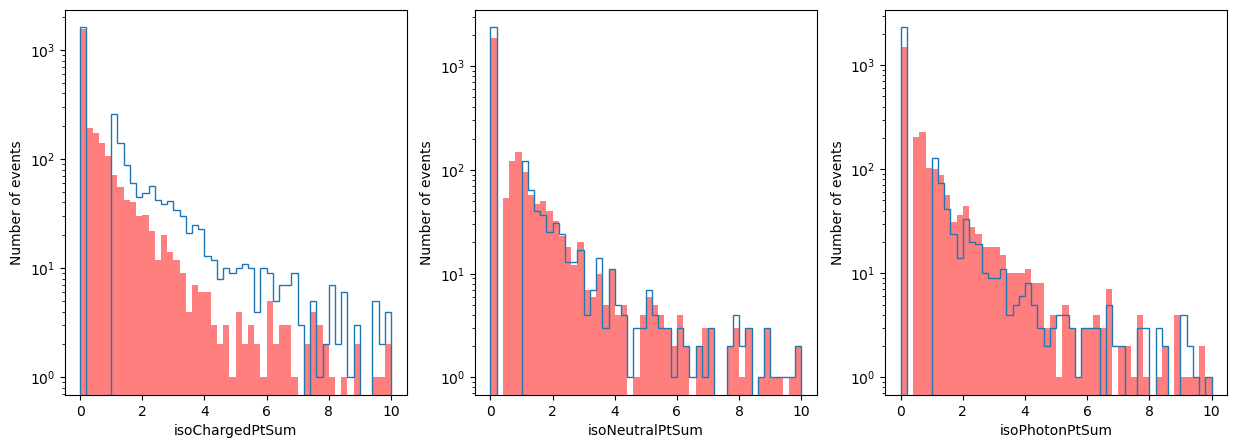

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, var in enumerate(['isoChargedPtSum', 'isoNeutralPtSum', 'isoPhotonPtSum']):
    plot_data = [
        isolation_scores_v3[j][i+1][(data['class_id'][j] == 2)] for j in range(2000)
    ]
    ax[i].hist(
        np.concatenate(data_muons[var]),
        bins=50,
        range=(0, 10),
        histtype="stepfilled",
        color="red",
        alpha=0.5,
        label='CMS'
    )
    ax[i].hist(
        np.concatenate(plot_data),
        bins=50,
        range=(0, 10),
        histtype='step',
        label='My'
    )
    ax[i].set_yscale('log')
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Number of events")
plt.show()

In [60]:
idx = 0
print(
    isolation_scores_v3[idx][1][data["class_id"][idx] == 2],
    data_muons['isoChargedPtSum'][idx],
    '\n' + '-' * 50 + '\n',
    isolation_scores_v3[idx][2][data["class_id"][idx] == 2],
    data_muons['isoNeutralPtSum'][idx],
    '\n' + '-' * 50 + '\n',
    isolation_scores_v3[idx][3][data["class_id"][idx] == 2],
    data_muons['isoPhotonPtSum'][idx],
)

[0.       2.930355] [1.0701604 3.9408724] 
--------------------------------------------------
 [0. 0.] [0. 0.] 
--------------------------------------------------
 [1.9084004 0.       ] [2.4264908  0.65040314]


In [223]:
data_muons['isoChargedPtSum'][0]# + data_muons['isoNeutralPtSum'][0]

array([1.4956993, 4.230817 , 0.       ], dtype=float32)

In [12]:
%timeit calculate_isolation(data["pt"][10], data["eta"][10], data["phi"][10], data["class_id"][10])

20.1 ms ± 130 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
%timeit calculate_isolation_v2(data["pt"][10], data["eta"][10], data["phi"][10], data["class_id"][10])

1.05 ms ± 4.06 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
%timeit calculate_isolation_v3(data["pt"][10], data["eta"][10], data["phi"][10], data["class_id"][10])

1.05 ms ± 4.06 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [32]:
def plot_event(data, index, isolation_scores=None, muon_data=None, pt_cut=0):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f"Event {index}")
    ax.set_xlabel("eta")
    ax.set_ylabel("phi")

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3.2, 3.2)
    ax.set_aspect("equal")
    ax.grid()

    # Plot the particles
    eta = data["eta"][index]
    phi = data["phi"][index]
    pt = data["pt"][index]
    pt_mask = pt > pt_cut
    iso_scores = isolation_scores[index] if isolation_scores is not None else None
    class_id = data["class_id"][index]
    lepton_mask = (class_id == 1) | (class_id == 2) & (pt_mask)
    iso_scores = iso_scores[pt_mask & lepton_mask]
    for i, class_name in enumerate(["Ch. H", "El", "Mu", "Neut", "Gamma"]):
        # Plot the particles of each class
        # Use a different color for each class
        mask = (class_id == i) & (pt_mask)
        ax.scatter(
            eta[mask],
            phi[mask],
            c=f"C{i}",
            s=100,
            label=class_name,
        )
    if iso_scores is not None:
        for i, score in enumerate(iso_scores):
            ax.annotate(
                f"{score:.3f}",
                (eta[lepton_mask][i], phi[lepton_mask][i]),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=12,
            )
    if muon_data is not None:
        muon_eta = muon_data["eta"][index]
        muon_phi = muon_data["phi"][index]
        muon_mask = muon_data["pt"][index] > pt_cut
        ax.scatter(
            muon_eta[muon_mask],
            muon_phi[muon_mask],
            c="black",
            s=120,
            label="Muon",
            marker="*",
        )
    ax.legend()
    fig.show()

In [33]:
data_muons['pfreliso04all'][:10]

array([array([0.21395777, 0.90515035], dtype=float32),
       array([0.], dtype=float32), array([0.29500452], dtype=float32),
       array([0.04343044, 0.0222647 ], dtype=float32),
       array([0.19541243], dtype=float32),
       array([0.        , 0.11583302, 0.38333955], dtype=float32),
       array([0.05209493, 0.03257203], dtype=float32),
       array([0.05821397, 0.12306201], dtype=float32),
       array([   0., -999.], dtype=float32),
       array([ 2.3478648e-02,  1.1272787e-01, -9.9900000e+02], dtype=float32)],
      dtype=object)

In [34]:
isolation_scores[1][data['class_id'][1] == 2]

array([0.], dtype=float32)

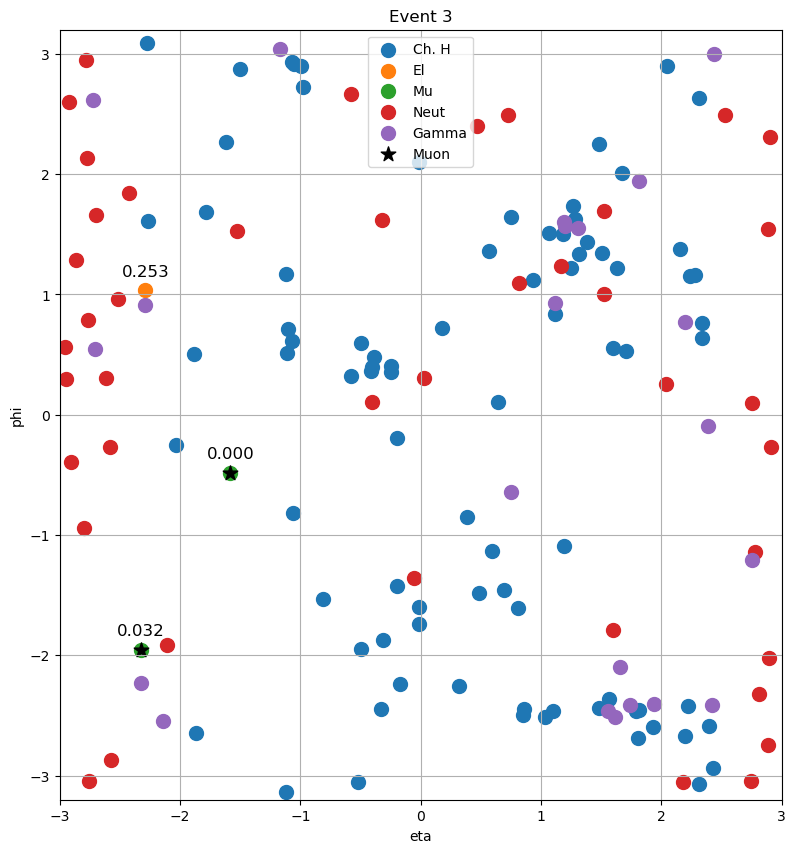

In [35]:
plot_event(data, 3, isolation_scores, muon_data=data_muons, pt_cut=1)

In [61]:
def extract_muon_iso(isolation_scores, data, pt_cut = 0):
    muon_iso = []
    for i in range(len(isolation_scores)):
        mask = (data['pt'][i] > pt_cut) & (data['class_id'][i] == 2)
        muon_iso.append(isolation_scores[i][0][mask])
    return muon_iso

In [62]:
# muon_iso = extract_muon_iso(isolation_scores, data, pt_cut=3)
muon_iso_v3 = extract_muon_iso(isolation_scores_v3, data, pt_cut=3)

In [63]:
iso_cms = data_muons['pfreliso04all'][:len(isolation_scores_v3)]

In [64]:
muons_pt = data_muons['pt']

In [65]:
data['pt'][0][data['class_id'][0] == 2]

array([16.342716,  5.07239 ], dtype=float32)

In [66]:
muons_pt[0]

array([16.342716,  5.07239 ], dtype=float32)

In [67]:
muon_iso_v3[0]

array([0.11677376, 0.577707  ], dtype=float32)

In [68]:
iso_cms[0]

array([0.21395777, 0.90515035], dtype=float32)

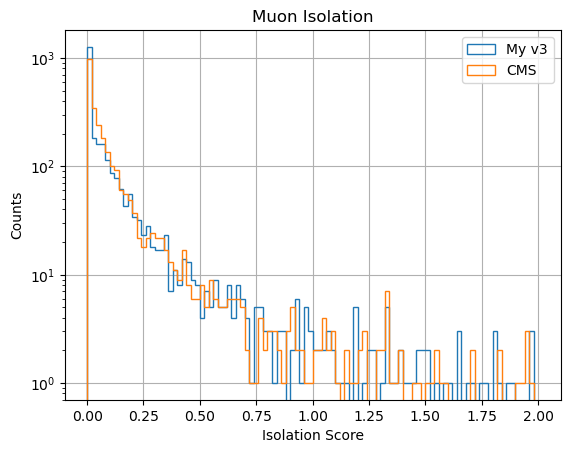

In [69]:
plt.hist(
    np.concatenate(muon_iso_v3),
    bins=100,
    range=(0, 2),
    histtype="step",
    label="My v3",
)

plt.hist(
    np.concatenate(iso_cms)[np.concatenate(iso_cms) > -1],
    bins=100,
    range=(0, 2),
    histtype="step",
    label="CMS",
)
plt.legend()
plt.title("Muon Isolation")
plt.ylabel("Counts")
plt.grid()
plt.yscale("log")
plt.xlabel("Isolation Score")
plt.show()

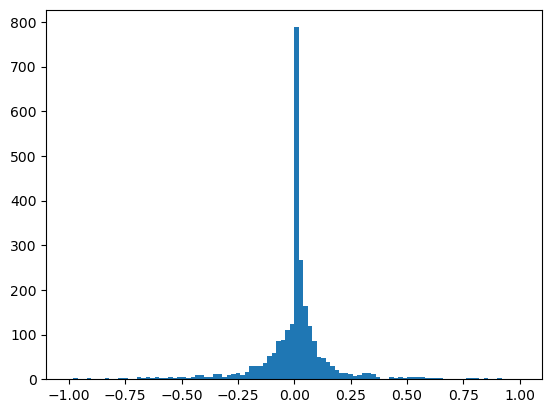

In [70]:
plt.hist(np.concatenate(iso_cms)[np.concatenate(iso_cms) > -1][:4773] - np.concatenate(muon_iso_v3), bins=100, range=(-1, 1))
# plt.yscale('log')
plt.show()